# Magnons from time-dependent Hartree-Fock
You can think of a magnon as the same kind of object as an exciton: a bound two-particle
excitation of a mean-field state, made of electron-hole pairs whose electron and hole have opposite
spin rather than the same spin. So the Bethe-Salpeter equation of the exciton notebook already
describes it, and `h.get_magnon_bands(method="tdhf")` is that equation restricted to the spin-flip
pairs, which is time-dependent Hartree-Fock on top of the converged mean field. Because it works in
the electron-hole pair index, it carries onsite and neighbor-shell density-density interactions,
and exchange interactions together with their transverse part $J/2(S^+_iS^-_j+\mathrm{h.c.})$,
which no density-density matrix can write. The magnon energies come out as eigenvalues, with no
frequency grid and no broadening.

The built-in check is the Goldstone theorem. A state that orders magnetically without spin-orbit
coupling breaks spin rotation symmetry spontaneously, so a uniform spin rotation costs no energy and
there must be a magnon at exactly zero energy at $Q=0$. `h.get_goldstone_residual()` measures how
far the calculation is from it, and it comes out of the order of the tolerance the mean field was
converged to. The mean field and the magnon have to be solved on the same k-mesh, otherwise the
acoustic branch picks up a spurious gap.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.meanfield import VJinteraction

### Magnon bands for onsite, neighbor-shell and exchange interactions
Let us converge the Néel state of the honeycomb lattice at half filling with an onsite $U$ alone,
with a first-neighbor density-density $V_1$ on top, and with a first-neighbor exchange $J_1$ on
top, and compute the two magnon branches of each along the high-symmetry path. In all three the
acoustic branch starts at zero at the zone center, and the Goldstone residual printed before each
dispersion says it does so to the tolerance of the mean field. The neighbor-shell $V_1$ reduces the
antiferromagnetic moment and reshapes the acoustic branch, deepening its minima along the path,
while the exchange $J_1$ increases the moment and stiffens the magnons everywhere.

U=3 | moment = 0.448 | Goldstone residual = 1.7e-10


U=3, V_1=0.5 | moment = 0.330 | Goldstone residual = 1.9e-10


U=3, J_1=0.5 | moment = 0.573 | Goldstone residual = 7.9e-11


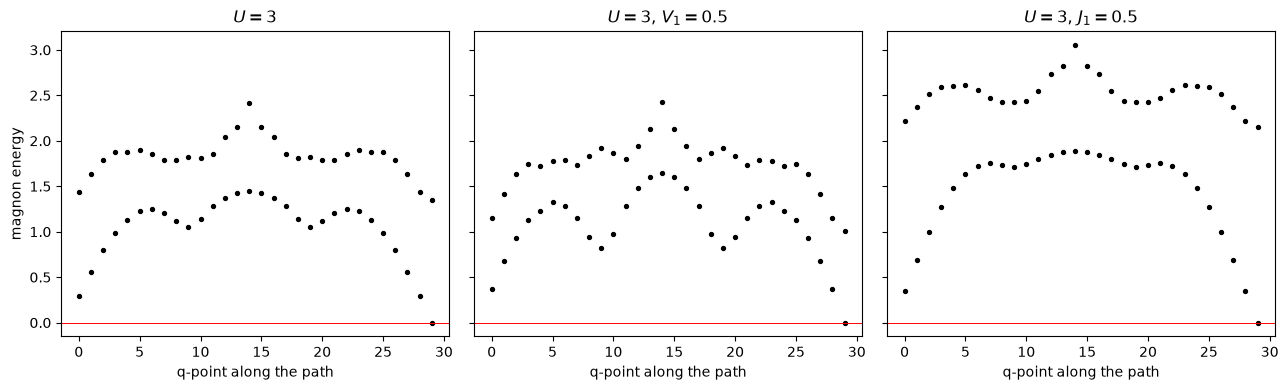

In [2]:
nk = 6 # the same k-mesh for the mean field and for the magnons
g = geometry.honeycomb_lattice()
cases = [("$U=3$",dict(U=3.0)),
         ("$U=3$, $V_1=0.5$",dict(U=3.0,V1=0.5)),
         ("$U=3$, $J_1=0.5$",dict(U=3.0,J1=0.5))]
hmfs = [] # store the mean-field Hamiltonians
fig,axs = plt.subplots(1,3,figsize=(13,4),sharey=True)
for ax,(label,kw) in zip(axs,cases):
    hmf = VJinteraction(g.get_hamiltonian(),filling=0.5,mf="antiferro",nk=nk,
                        maxerror=1e-10,mix=0.9,**kw).hamiltonian # Neel-ordered insulator
    hmfs.append(hmf)
    print(label.replace("$",""),"| moment = %.3f"%np.abs(hmf.get_vev("sz")[0]),
          "| Goldstone residual = %.1e"%hmf.get_goldstone_residual(nk=nk))
    qs,es = hmf.get_magnon_bands(method="tdhf",nk=nk,nq=30,n=2) # two lowest magnon branches
    ax.scatter(qs,es.real,c="black",s=8)
    ax.axhline(0.,c="red",lw=0.7)
    ax.set_title(label) ; ax.set_xlabel("q-point along the path")
axs[0].set_ylabel("magnon energy")
plt.tight_layout()
plt.show()

### The lowest magnon over the Brillouin zone
`h.get_magnon_energies(Q=...)` gives the magnon spectrum at a single momentum, which does not have
to belong to the k-mesh, since the pair basis is diagonalized at $k$ and $k+Q$ independently.
Scanning it over the whole Brillouin zone gives a map of the lowest magnon of the state with $U$
and $V_1$: the Goldstone mode is the dark point at the zone center, from which the energy grows
linearly in every direction, as it does for an antiferromagnet, and the magnon is most expensive at
the middle of the edges of the zone. The white hexagon is the first Brillouin zone.

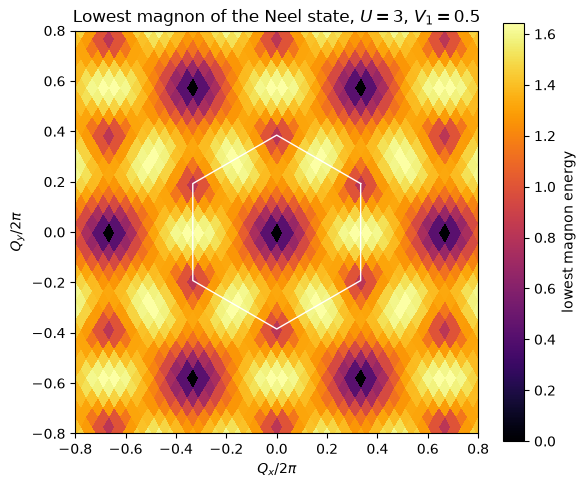

In [3]:
hmf = hmfs[1] # the mean field with U and V1
n = 15 # Q-points per direction
E = np.zeros((n,n))
for i1 in range(n):
    for i2 in range(n):
        E[i1,i2] = hmf.get_magnon_energies(Q=[i1/n,i2/n,0.],nk=nk,n=1)[0].real # lowest magnon at Q

b1,b2 = np.array(g.b1),np.array(g.b2) # reciprocal lattice vectors
Kc = 2./3.*b1 - 1./3.*b2 # a K point, a corner of the Brillouin zone
angles = np.linspace(0.,2.*np.pi,7) + np.arctan2(Kc[1],Kc[0])
hexagon = np.sqrt(Kc.dot(Kc))*np.array([np.cos(angles),np.sin(angles)])
fig = plt.figure(figsize=(6,5))
for s1 in [-2,-1,0,1]: # repeat the zone to show its surroundings
    for s2 in [-2,-1,0,1]:
        i1 = (np.arange(n+1)-0.5)/n + s1 ; i2 = (np.arange(n+1)-0.5)/n + s2
        K1,K2 = np.meshgrid(i1,i2,indexing="ij")
        X = K1*b1[0] + K2*b2[0] ; Y = K1*b1[1] + K2*b2[1]
        im = plt.pcolormesh(X,Y,E,cmap="inferno",shading="flat",vmin=0.,vmax=E.max())
plt.plot(hexagon[0],hexagon[1],c="white",lw=1)
plt.xlim(-0.8,0.8) ; plt.ylim(-0.8,0.8) ; plt.gca().set_aspect("equal")
plt.colorbar(im,label="lowest magnon energy")
plt.xlabel(r"$Q_x/2\pi$") ; plt.ylabel(r"$Q_y/2\pi$")
plt.title("Lowest magnon of the Neel state, $U=3$, $V_1=0.5$")
plt.tight_layout()
plt.show()